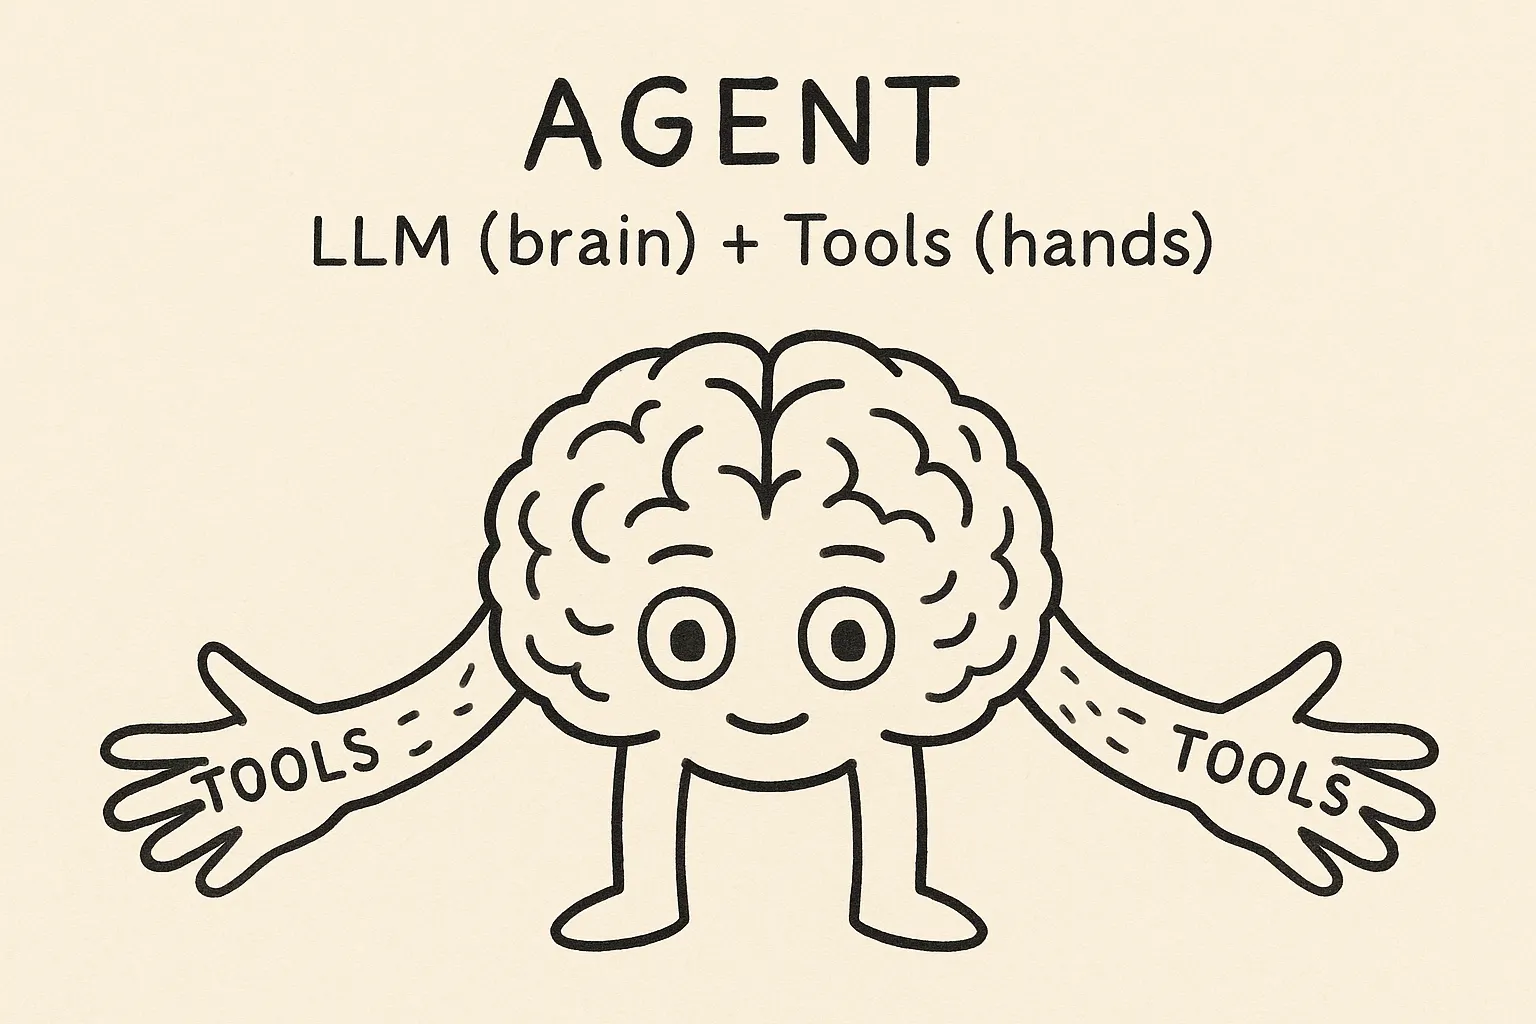

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain.chat_models import init_chat_model

model = init_chat_model("groq:llama-3.1-8b-instant")

response = model.invoke("What is recent IPL news?")

print(response.content)

e:\Agents_Langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Since my knowledge cutoff is December 2023, I'll provide information on recent IPL news up to that date. However, please note that I may not have information on very recent events.

Some recent IPL news up to my knowledge cutoff includes:

1. **Rohit Sharma as BCCI President Elect**: In December 2023, Rohit Sharma was elected as the President of the Board of Control for Cricket in India (BCCI). This move is seen as a significant development in Indian cricket, with Rohit Sharma being a prominent figure in the sport.
2. **IPL 2023 Winners**: The Gujarat Titans won the IPL 2023 championship, defeating the Chennai Super Kings in the final. 
3. **IPL Mega Auction 2023**: In December 2022, the Indian Premier League (IPL) held a mega auction for the 2023 season. Several players, including big names like Shreyas Iyer, R Ashwin, and Ishan Kishan, were picked up by various teams.

Please note that there may be more recent news or updates that I am not aware of.


#### DuckDuckGo Search Tool

- DuckDuckGoSearchRun is a powerful tool within the LangChain framework that integrates DuckDuckGo's search functionality into your applications. 

- Designed for developers and AI practitioners, this tool allows you to perform web searches programmatically, retrieve real-time information, and integrate search results into your workflows. 

- Install - ddgs

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

result = search.invoke("Who won the IPL 2026 final between RCB and GT?")

print(result)

3 hours ago - Follow IPL | RCB 161/5 (18) vs GT 155/8 (Virat Kohli 75(42) Jitesh Sharma 11(14)) | Royal Challengers Bengaluru vs Gujarat Titans, Final, Indian Premier League 2026 live with live scores, ball-by-ball commentary, highlights, videos, news, and ... June 1, 2026 - Royal Challengers Bengaluru (RCB) etched their name deeper into IPL history, defeating Gujarat Titans (GT) by five wickets in the TATA IPL 2026 final at the Narendra Modi Stadium to successfully defend their crown. June 1, 2026 - RCB vs GT Live Score, IPL 2026 Final: : A half-century from star batter Virat Kohli helped Royal Challengers Bengaluru (RCB) make history, successfully defending their Indian Premier League (IPL) title, getting their overall second title, beating ... June 1, 2026 - Virat Kohli delivered a captain's knock with an unbeaten 75 as Royal Challengers Bengaluru (RCB) defeated Gujarat Titans (GT) by five wickets to lift their second successive IPL title on Sunday. 3 weeks ago - Over 18 • RCB 161/5

In [5]:
search.name

'duckduckgo_search'

In [7]:
search.description

'A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.'

In [8]:
search.args

{'query': {'description': 'search query to look up',
  'title': 'Query',
  'type': 'string'}}

In [9]:
# Let's try with groq model

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [13]:
parser = StrOutputParser()

In [14]:
llm = ChatGroq(model="llama-3.1-8b-instant")

prompt = ChatPromptTemplate.from_template("""
You are a helpful cricket analyst.

Question: {question}

Search Results:
{search}

Provide a concise answer based on the search results.
""") 

In [15]:
chain = prompt | llm | parser

In [16]:
result = chain.invoke({
    "question": "Who won the IPL 2026 final?",
    "search": result
})

In [17]:
result

'Royal Challengers Bengaluru (RCB) won the IPL 2026 final, defeating Gujarat Titans (GT) by 5 wickets.'

### Tavily Search

In [19]:
from langchain_tavily import TavilySearch
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

tavily_search = TavilySearch()

tavily_result = tavily_search.invoke("What is the current Stock value NSE?")

print(tavily_result['results'][0]['content'])

An information platform for unlisted & pre-IPO sharesNot a SEBI-recognised stock exchange or trading platformAll prices are indicative

An information platform for unlisted & pre-IPO sharesNot a SEBI-recognised stock exchange or trading platformAll prices are indicative

UnlistedZone

Sign inOpen an account

Home › Shares › NSE India Limited

NSE India Limited logo

# NSE India Limited

Financial Services

₹2,095

Indicative price · for information

As of 10 Jul 2026

Indicative price history [...] | Particulars (cr) | Revenue (Fy26) | EPS (FY26) | Mcap (12.05.26) | P/E (FY26) |
 ---  --- 
| NSE | 16601 | 41.13 | 501188 | 49.2x |
| BSE | 4834 | 61.3 | 159417 | 64.1x |

## Corporate calendarEvents

17 Jun 2026

NSE filed DRHP

27 Apr 2026

NSE IPO – Shareholder OFS Notice

12 Mar 2026

NSE Appoints Intermediaries for IPO

06 Feb 2026

Q3FY2026 Results of NSE

04 Nov 2025

6MFY2026 Results of NSE

27 Aug 2025

dividend 35Dividend of NSE

25 Aug 2025

NSE Announces 33rd AGM and Record Dat

In [20]:
tavily_result['results']

[{'url': 'https://unlistedzone.com/shares/nse-india-limited-unlisted-shares',
  'title': 'NSE India Limited Unlisted Share Price — Buy Sell with UnlistedZone',
  'content': 'An information platform for unlisted & pre-IPO sharesNot a SEBI-recognised stock exchange or trading platformAll prices are indicative\n\nAn information platform for unlisted & pre-IPO sharesNot a SEBI-recognised stock exchange or trading platformAll prices are indicative\n\nUnlistedZone\n\nSign inOpen an account\n\nHome › Shares › NSE India Limited\n\nNSE India Limited logo\n\n# NSE India Limited\n\nFinancial Services\n\n₹2,095\n\nIndicative price · for information\n\nAs of 10 Jul 2026\n\nIndicative price history [...] | Particulars (cr) | Revenue (Fy26) | EPS (FY26) | Mcap (12.05.26) | P/E (FY26) |\n ---  --- \n| NSE | 16601 | 41.13 | 501188 | 49.2x |\n| BSE | 4834 | 61.3 | 159417 | 64.1x |\n\n## Corporate calendarEvents\n\n17 Jun 2026\n\nNSE filed DRHP\n\n27 Apr 2026\n\nNSE IPO – Shareholder OFS Notice\n\n12 Mar

In [21]:
print(tavily_search.name)
print(tavily_search.description)
print(tavily_search.args)

tavily_search
A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.
{'query': {'description': 'Search query to look up', 'title': 'Query', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user explicitly requests information from specific websites (e.g., "Find climate data from nasa.gov")\n        2. The user mentions an organization or company without specifying the domain (e.g., "Find information about iPhones from Apple")\n\n        In both cases, you should determine the

In [22]:
from langchain_community.tools import ShellTool

shell_tool = ShellTool()

result = shell_tool.invoke("Dir")

print(result)

Executing command:
 Dir
 Volume in drive E is New Volume
 Volume Serial Number is DCCF-7778

 Directory of e:\Agents_Langgraph\notebooks

06-08-2026  01:15 PM    <DIR>          .
06-08-2026  07:56 AM    <DIR>          ..
06-08-2026  02:12 PM            13,923 1_demo_agent.ipynb
06-08-2026  12:51 PM            43,589 2_demo_workflow.ipynb
06-08-2026  12:55 PM            20,893 3_chatbot_workflow.ipynb
06-08-2026  01:04 PM            14,338 4_chatbot_memory.ipynb
06-08-2026  01:14 PM             1,971 5_demo_agent.ipynb
20-06-2026  08:45 PM             1,012 chatbot_backend.py
20-06-2026  09:32 PM             3,245 chatbot_FE_streaming_threading.py
06-08-2026  03:03 PM         1,380,353 tools_demo.ipynb
               8 File(s)      1,479,324 bytes
               2 Dir(s)  179,874,017,280 bytes free



e:\Agents_Langgraph\.venv\Lib\site-packages\langchain_community\tools\shell\tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


In [23]:
# Basic information 
print(shell_tool.name)
print(shell_tool.description)
print(shell_tool.args)

terminal
Run shell commands on this Windows machine.
{'commands': {'anyOf': [{'type': 'string'}, {'items': {'type': 'string'}, 'type': 'array'}], 'description': 'List of shell commands to run. Deserialized using json.loads', 'title': 'Commands'}}


In [25]:
# Initialize Shell Tool
shell_tool = ShellTool()

# Execute command
shell_output = shell_tool.invoke("Dir")

# Initialize Groq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

prompt = ChatPromptTemplate.from_template("""
Analyze the following shell output:

{output}

Explain what it means.
""")

chain = prompt | llm | StrOutputParser()

response = chain.invoke({
    "output": shell_output
})

print(response)

e:\Agents_Langgraph\.venv\Lib\site-packages\langchain_community\tools\shell\tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


Executing command:
 Dir
This is a shell output, specifically a directory listing, from a Windows system. Here's a breakdown of what it means:

**Volume Information**

* `Volume in drive E is New Volume`: This indicates that the directory listing is for the `E:` drive, which is labeled as "New Volume".
* `Volume Serial Number is DCCF-7778`: This is a unique identifier for the `E:` drive.

**Directory Listing**

* `Directory of e:\Agents_Langgraph\notebooks`: This specifies the directory being listed, which is `e:\Agents_Langgraph\notebooks`.
* The following lines list the files and subdirectories in the `notebooks` directory:
	+ `06-08-2026  01:15 PM    <DIR>          .`: This is the current directory (`.`) and its last modification date and time.
	+ `06-08-2026  07:56 AM    <DIR>          ..`: This is the parent directory (`..`) and its last modification date and time.
	+ The remaining lines list files with their last modification date and time, size in bytes, and filename:
		- `1_demo

### Wikipedia

In [27]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

result = wiki_tool.invoke("LLM")

e:\Agents_Langgraph\.venv\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file e:\Agents_Langgraph\.venv\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


In [29]:
print(result)

Page: Large language model
Summary: A large language model (LLM) is an AI model (typically a neural network) trained on a vast amount of text for natural language processing tasks, especially language generation. LLMs can typically generate, summarize, translate, and analyze text in many contexts, and are a foundational technology behind modern chatbots. Biased or inaccurate training data can make an LLM's output less reliable.
LLMs are typically based on transformer architecture. Generative pre-trained transformers (GPTs) are a type of LLM that is pre-trained to predict the next word. GPTs are then often fine-tuned to follow instructions and to behave as assistants.
Benchmark evaluations for LLMs attempt to measure model reasoning, factual accuracy, alignment, and safety.



Page: List of large language models
Summary: A large language model (LLM) is a type of machine learning model designed for natural language processing tasks such as language generation. LLMs are language models wi

### Custom Tool


##### Tool Creation with @tool decorator

In [34]:
# Import tool class from langchain
from langchain_core.tools import tool

In [30]:
# Create your own function
# Doc string is highly recomended it will helps llm to what to do.
def multiply(a,b):
    '''Multiply two numbers''' # This is must
    return a*b

In [31]:
# Add type hints
def multiply(a:int,b:int) -> int:
    '''Multiply two numbers'''
    return a*b

In [32]:
print(multiply(3,4))

12


In [35]:
# add tool decorator

@tool
def multiply(a:int,b:int) -> int:
    '''Multiply two numbers'''
    return a*b

In [36]:
multiply

StructuredTool(name='multiply', description='Multiply two numbers', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x00000248583DAFC0>)

In [37]:
print(multiply(3,4))

TypeError: 'StructuredTool' object is not callable

In [38]:
print(multiply.invoke({"a": 3, "b": 4}))

12


In [39]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [40]:
# Basic information 
print(multiply.args_schema)

<class 'langchain_core.utils.pydantic.multiply'>


##### Tool Creation with Pydantic - Structured Tool

In [41]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field

import warnings
warnings.filterwarnings("ignore")

In [42]:
# Define a Pydantic model for the tool's arguments
class MultiplyArgs(BaseModel):
    a: int = Field(required=True, description="The first number to multiply")
    b: int = Field(required=True, description="The second number to multiply")

In [43]:
# Define the function that performs the multiplication
def multiply(a: int, b: int) -> int:
    '''Multiply two numbers'''
    return a * b

In [44]:
# Create a StructuredTool using the function and the argument schema
# important to provide description for the tool, it will helps llm to understand when to use this tool.
# The main tool creation happens here, we are creating a tool from a function and providing the argument schema and description.
multiply_tool = StructuredTool.from_function(
    func=multiply,
    name="multiply",
    args_schema=MultiplyArgs,
    description="Multiplies two numbers together."
)

In [48]:
print(multiply_tool.invoke({"a": 3, "b": 4}))

12


In [46]:
multiply_tool

StructuredTool(name='multiply', description='Multiplies two numbers together.', args_schema=<class '__main__.MultiplyArgs'>, func=<function multiply at 0x00000248583D8CC0>)

In [34]:
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args)

multiply
Multiplies two numbers together.
{'a': {'description': 'The first number to multiply', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to multiply', 'title': 'B', 'type': 'integer'}}


##### Tool creation using BaseTool Class


In [35]:
from langchain_core.tools import BaseTool
from pydantic import BaseModel, Field
from typing import Type

In [37]:
class AddArgs(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

In [38]:
# Define a custom tool by inheriting from BaseTool
class AdditionTool(BaseTool):
    name: str = "addition"
    description: str = "Adds two numbers together."
    args_schema: Type[BaseModel] = AddArgs

    def _run(self, a: int, b: int) -> int:
        '''Add two numbers'''
        return a + b

In [39]:
# Create an instance of the tool
addition_tool = AdditionTool()

result = addition_tool.invoke({"a":5,"b":6})

print(result)

11


In [40]:
# Basic information
print(addition_tool.name)
print(addition_tool.description)
print(addition_tool.args)

addition
Adds two numbers together.
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


#### Toolkit

- A toolkit is just a collection(bundle) of related tools that surves a common purpose - packaged together for convenience and reusability.
- For example - CalculatorTool
    - add
    - sub
    - mul
    - div
- In langchain, GoogleDriveToolKit
    - GoogleDriveCreateFileTool - upload a file
    - GoogleDriveSearchFileTool - search for a file by name or tool
    - GoogleDriveReadFileTool - Read content of a file



In [49]:
from langchain_core.tools import tool

@tool
def subtract(a: int, b: int) -> int:
    '''Subtract two numbers'''
    return a - b

@tool
def divide(a: int, b: int) -> float:
    '''Divide two numbers'''
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b

@tool
def power(a: int, b: int) -> int:
    '''Raise a to the power of b'''
    return a ** b

@tool
def modulus(a: int, b: int) -> int:
    '''Get the modulus of a and b'''
    if b == 0:
        raise ValueError("Cannot modulus by zero")
    return a % b

@tool
def floor_divide(a: int, b: int) -> int:
    '''Floor divide a by b'''
    if b == 0:
        raise ValueError("Cannot floor divide by zero")
    return a // b

@tool
def addition(a: int, b: int) -> int:
    '''Add two numbers'''
    return a + b

In [50]:
# Create a tool kit to group all the tools together, it will helps llm to find the right tool when needed.
class CalculatorToolKit:
    def get_tools(self):
        return [addition, subtract, divide, power, modulus, floor_divide]

In [51]:
# Create an instance of the tool
calculator_toolkit = CalculatorToolKit()
tools = calculator_toolkit.get_tools()
tools

[StructuredTool(name='addition', description='Add two numbers', args_schema=<class 'langchain_core.utils.pydantic.addition'>, func=<function addition at 0x00000248582165C0>),
 StructuredTool(name='subtract', description='Subtract two numbers', args_schema=<class 'langchain_core.utils.pydantic.subtract'>, func=<function subtract at 0x00000248583DBEC0>),
 StructuredTool(name='divide', description='Divide two numbers', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000024858217560>),
 StructuredTool(name='power', description='Raise a to the power of b', args_schema=<class 'langchain_core.utils.pydantic.power'>, func=<function power at 0x00000248582179C0>),
 StructuredTool(name='modulus', description='Get the modulus of a and b', args_schema=<class 'langchain_core.utils.pydantic.modulus'>, func=<function modulus at 0x0000024858216CA0>),
 StructuredTool(name='floor_divide', description='Floor divide a by b', args_schema=<class 'langchain_core.utils.p

In [44]:
#### Connecting Tools with LLM

In [52]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.1-8b-instant")

In [53]:
# Define a addition tool using the tool decorator

@tool
def addition(a: int, b: int) -> int:
    '''Given two numbers a and b, return their sum.'''
    return a + b

In [54]:
import torch


In [55]:
torch.cuda.is_available()

False

In [56]:
# tool bindings

llm_with_tools = llm.bind_tools([addition])

In [57]:
# tool bindings
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000248583BCF10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000248586305D0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'addition', 'description': 'Given two numbers a

In [58]:
# tool invocation
llm_with_tools.invoke("Hello I am Anant. How are you?")

AIMessage(content="Hello Anant, I'm functioning properly, thanks for asking. What's on your mind? Would you like to talk about something or perhaps have a question?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 238, 'total_tokens': 271, 'completion_time': 0.065208156, 'completion_tokens_details': None, 'prompt_time': 0.029008513, 'prompt_tokens_details': None, 'queue_time': 0.056916038, 'total_time': 0.094216669}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fd690-b534-7be0-8cf5-f69ee4ff0009-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 238, 'output_tokens': 33, 'total_tokens': 271})

In [59]:
# tool invocation
llm_with_tools.invoke("What is the sum of 5 and 6?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5x89mnpt2', 'function': {'arguments': '{"a":5,"b":6}', 'name': 'addition'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 239, 'total_tokens': 258, 'completion_time': 0.024975755, 'completion_tokens_details': None, 'prompt_time': 0.013473991, 'prompt_tokens_details': None, 'queue_time': 0.048487679, 'total_time': 0.038449746}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fd691-0bed-75b1-a2c7-7957d0dc35fc-0', tool_calls=[{'name': 'addition', 'args': {'a': 5, 'b': 6}, 'id': '5x89mnpt2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 239, 'output_tokens': 19, 'total_tokens': 258})

In [60]:
# tool invocation with tool calls
llm_with_tools.invoke("What is the sum of 5 and 6?").tool_calls

[{'name': 'addition',
  'args': {'a': 5, 'b': 6},
  'id': '7ckj84bb5',
  'type': 'tool_call'}]

In [61]:
addition.invoke(llm_with_tools.invoke("What is the sum of 5 and 6?").tool_calls[0])

ToolMessage(content='11', name='addition', tool_call_id='p0ssbs7p9')

In [62]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
query = HumanMessage(content="What is the sum of 5 and 6?")
messages = [query]
messages

[HumanMessage(content='What is the sum of 5 and 6?', additional_kwargs={}, response_metadata={})]

In [64]:
result = llm_with_tools.invoke("What is the sum of 5 and 6?")
messages.append(result)

In [65]:
messages

[HumanMessage(content='What is the sum of 5 and 6?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0svjwhbh0', 'function': {'arguments': '{"a":5,"b":6}', 'name': 'addition'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 239, 'total_tokens': 258, 'completion_time': 0.027264872, 'completion_tokens_details': None, 'prompt_time': 0.019050693, 'prompt_tokens_details': None, 'queue_time': 0.04960884, 'total_time': 0.046315565}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fd692-ba84-7832-be61-49b9f7f0a3fb-0', tool_calls=[{'name': 'addition', 'args': {'a': 5, 'b': 6}, 'id': '0svjwhbh0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 239, 'output_tokens': 19, 'total_tokens': 258}),
 AIMessage(cont

In [66]:
tool_results = addition.invoke(result.tool_calls[0])
tool_results

ToolMessage(content='11', name='addition', tool_call_id='r4r9r0rcw')

In [67]:
messages.append(tool_results)
messages

[HumanMessage(content='What is the sum of 5 and 6?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0svjwhbh0', 'function': {'arguments': '{"a":5,"b":6}', 'name': 'addition'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 239, 'total_tokens': 258, 'completion_time': 0.027264872, 'completion_tokens_details': None, 'prompt_time': 0.019050693, 'prompt_tokens_details': None, 'queue_time': 0.04960884, 'total_time': 0.046315565}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fd692-ba84-7832-be61-49b9f7f0a3fb-0', tool_calls=[{'name': 'addition', 'args': {'a': 5, 'b': 6}, 'id': '0svjwhbh0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 239, 'output_tokens': 19, 'total_tokens': 258}),
 AIMessage(cont

In [68]:
print(llm_with_tools.invoke(messages).content)

The sum of 5 and 6 is 11.


In [69]:
from langchain_tavily import TavilySearch
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

tavily_search = TavilySearch()

In [70]:
print(tavily_search.name)
print(tavily_search.description)
print(tavily_search.args)

tavily_search
A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.
{'query': {'description': 'Search query to look up', 'title': 'Query', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user explicitly requests information from specific websites (e.g., "Find climate data from nasa.gov")\n        2. The user mentions an organization or company without specifying the domain (e.g., "Find information about iPhones from Apple")\n\n        In both cases, you should determine the

In [71]:
from langchain_core.tools import tool

@tool
def subtract(a: int, b: int) -> int:
    '''Subtract two numbers'''
    return a - b

@tool
def divide(a: int, b: int) -> float:
    '''Divide two numbers'''
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b

@tool
def power(a: int, b: int) -> int:
    '''Raise a to the power of b'''
    return a ** b

@tool
def modulus(a: int, b: int) -> int:
    '''Get the modulus of a and b'''
    if b == 0:
        raise ValueError("Cannot modulus by zero")
    return a % b

@tool
def floor_divide(a: int, b: int) -> int:
    '''Floor divide a by b'''
    if b == 0:
        raise ValueError("Cannot floor divide by zero")
    return a // b

@tool
def addition(a: int, b: int) -> int:
    '''Add two numbers'''
    return a + b

In [72]:
llms = ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools = llms.bind_tools([addition, subtract, divide, power, modulus, floor_divide, tavily_search])

In [73]:
messages = [SystemMessage(content="You are a helpful assistant that can perform various mathematical operations and search the web for information.")]
messages.append(HumanMessage(content="What is the current news on Stock Market?"))

In [74]:
result = llm_with_tools.invoke(messages)
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qhm6t751r', 'function': {'arguments': '{"query":"current stock market news","search_depth":"advanced","topic":"finance"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'rdhcdhc57', 'function': {'arguments': '{"query":"stock market updates","search_depth":"advanced","topic":"finance"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 2047, 'total_tokens': 2109, 'completion_time': 0.096854508, 'completion_tokens_details': None, 'prompt_time': 0.163495035, 'prompt_tokens_details': None, 'queue_time': 0.055452064, 'total_time': 0.260349543}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fd695-5b8e-7290-8a8e-b56827e1fe96-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current stock

In [75]:
result.tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'current stock market news',
   'search_depth': 'advanced',
   'topic': 'finance'},
  'id': 'qhm6t751r',
  'type': 'tool_call'},
 {'name': 'tavily_search',
  'args': {'query': 'stock market updates',
   'search_depth': 'advanced',
   'topic': 'finance'},
  'id': 'rdhcdhc57',
  'type': 'tool_call'}]

In [76]:
tool_calls_result = tavily_search.invoke(result.tool_calls[0])

In [77]:
tool_calls_result

ToolMessage(content='{"query": "current stock market news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.thecurrent.com", "title": "The Current | The Current", "content": "EU AI Act in force: Brands operating in Europe must now label whether the content they produce is AI-generated or altered, leading some to worry about AI disclosure fatigue. It\'s over: Elon Musk\'s X and the World Federation of Advertisers settled their legal dispute after two years. Holding Firm: Jeff Green reaffirmed The Trade Desk\'s commitment to agencies as AI reshapes the advertising industry. EU approval: Paramount\'s planned Warner Bros. megamerger won conditional approval from the EU, with still faces a U.S. lawsuit. Snag in the merger: A judge pauses the Paramount-Warner Bros. New lawsuit against Paramount: A dozen states are suing to block Paramount Skydance\'s $110 billion takeover of Warner Bros. The World Cup was a win for brands. The World Cup generated a

In [78]:
messages.append(tool_calls_result)
messages

[SystemMessage(content='You are a helpful assistant that can perform various mathematical operations and search the web for information.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is the current news on Stock Market?', additional_kwargs={}, response_metadata={}),
 ToolMessage(content='{"query": "current stock market news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.thecurrent.com", "title": "The Current | The Current", "content": "EU AI Act in force: Brands operating in Europe must now label whether the content they produce is AI-generated or altered, leading some to worry about AI disclosure fatigue. It\'s over: Elon Musk\'s X and the World Federation of Advertisers settled their legal dispute after two years. Holding Firm: Jeff Green reaffirmed The Trade Desk\'s commitment to agencies as AI reshapes the advertising industry. EU approval: Paramount\'s planned Warner Bros. megamerger won conditional approv

1. LLM
2. Tools
3. Agents --> LLM(Brain)+Tools(Hands) --> Task

Create_agent --> langchain.agents

In [80]:
from langchain.agents import create_agent

In [81]:
# Initialize the agent with the LLM and tools
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")


agent = create_agent(
    model = "openai:gpt-4o-mini",
    tools = [addition, subtract, divide, power, modulus, floor_divide, tavily_search],
    system_prompt = "You are a helpful assistant. Be concise and accurate."
)

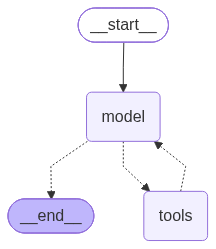

In [83]:
agent

In [84]:
result = agent.invoke(
    {"messages": 
        [
            {"role": "user", 
             "content": "What is the current temperature in Delhi"
             }
            ]
        }
)

result['messages'][-1].content

'The current temperature in Delhi is expected to be between 37°C and 39°C during the day, with minimum temperatures ranging from 26°C to 28°C. These temperatures are part of a forecast indicating that the weather will remain relatively stable over the coming days. For more details, you can check the full report [here](https://indianexpress.com/article/weather/elhi-weather-forecast-imd-july-monsoon-heat-humidity-10785255).'

In [75]:
result['messages'][-1].content

'The current temperature in New Delhi is 28°C, with a feels-like temperature of 36°C. Scattered light rain showers are expected today.'